# Walk-Forward Optimization -- VectorBT-Native, Multi-Asset

**Purpose.** `walk_forward.ipynb` validates the FULL production pipeline
(Strategy -> Signals -> PortfolioAllocator -> PositionSizer -> order-driven
backtest) out-of-sample. This notebook is a narrower, complementary tool: it
validates the RAW indicator/window choice itself, using vectorbt's own native
`rolling_split` + `MA.run_combs` + `Portfolio.from_signals` machinery directly
-- the exact technique "Conducting walk-forward optimization with VectorBT" -- 
run across every symbol in `config.UNIVERSE`, not just the book's single AAPL 
example.

**Why a separate notebook, and why native vectorbt instead of this project's
own `backtester.py`/`portfolio_engine.py`:** those modules add position
sizing, multi-asset capital allocation, and an order-driven execution model on
top of raw signals -- valuable for production, but it's also where every bug
in this project so far has come from (MultiIndex column mismatches between a
parameter grid and plain per-symbol prices). This notebook deliberately
avoids that entire layer. It asks a narrower, cleaner question -- "is this
`(fast_window, slow_window)` choice itself statistically robust, independent
of how positions get sized, and does the answer hold up across the whole
universe or just one name" -- using only vectorbt's own well-tested internals.
Its conclusions are inputs to `config.StrategyConfig` and to
`walk_forward.ipynb`, not a replacement for either.

**Why every section is multi-asset, not just a bolt-on at the end:**
`rolling_split` is validated (by vectorbt's own docs) against a single-column 
Series -- there's no tested multi-column usage to lean on. So the right way to 
make this genuinely multi-asset isn't to hand a 5-column DataFrame into one 
`rolling_split` call, it's to run the exact per-symbol pipeline in a loop and 
treat the PER-SYMBOL RESULTS as the unit of analysis everywhere -- data loading, 
splitting, optimization, statistics, stability, and visualization all operate on
`{symbol: results}` dictionaries from section 1 onward.

**What's added:**
1. Every symbol in `config.UNIVERSE`.
2. A statistical test (`scipy.stats.ttest_ind`) on IS-best vs. OOS Sharpe,
   run per-symbol AND pooled across the universe -- here it's interpreted,
   in both directions, with its limitations stated plainly.
3. Parameter stability analysis across folds AND across symbols -- stores the 
   winning `(fast, slow)` per fold and looks at whether that choice is stable, 
   let alone whether it's consistent name to name.
4. Visualization: Sharpe "surface" heatmaps per symbol, parameter selection
   frequency by symbol, parameter drift over time overlaid across symbols,
   and a cross-symbol scorecard.

## 0. Setup

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "config.py").exists() and (PROJECT_ROOT.parent / "config.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/davidyekara/Downloads/Algorithmic Trading Cookbook/VectorBT/Technical Strategies


In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scipy.stats as stats
import vectorbt as vbt
import matplotlib.pyplot as plt

# Deliberately NOT importing backtester / portfolio_engine / signal_generator --
# this notebook works directly against vectorbt, independent of this project's own 
# (more fragile) position-sizing layer.

import config
import database

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.figsize"] = (13, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Data (multi-asset)

Every symbol in `config.UNIVERSE`, loaded from this project's own market
database (same source every other notebook uses) rather than re-downloading
via `IBGateway` -- just reusing data already on disk, for the whole universe 
instead of one ticker.

Universe: ['AAPL', 'AMZN', 'MSFT', 'NVDA', 'GOOG']


,first_date,last_date,n_bars
symbol,,,
AAPL,2018-07-24,2026-08-17,2027
AMZN,2018-07-24,2026-08-17,2027
MSFT,2018-07-24,2026-08-17,2027
NVDA,2018-07-24,2026-08-17,2027
GOOG,2018-07-24,2026-08-17,2027


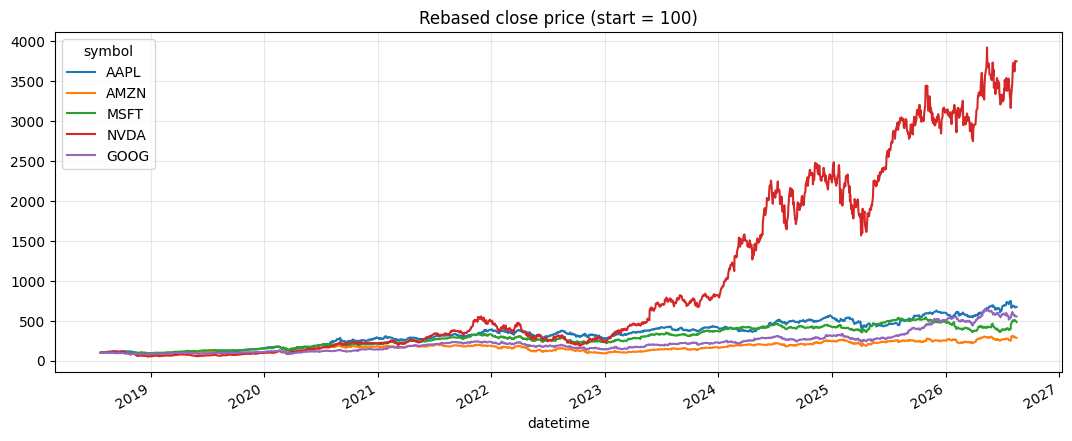

In [4]:
database.init_db()
all_prices = database.load_bars(config.UNIVERSE)
assert not all_prices.empty, "No data in DB yet -- run `python main.py refresh` first."

coverage = pd.DataFrame({
    "first_date": all_prices.apply(lambda s: s.first_valid_index()),
    "last_date": all_prices.apply(lambda s: s.last_valid_index()),
    "n_bars": all_prices.notna().sum(),
})
print(f"Universe: {list(all_prices.columns)}")
display(coverage)

(all_prices / all_prices.iloc[0] * 100).plot(title="Rebased close price (start = 100)")
plt.show()

## 2. Rolling walk-forward split (every symbol)

`rolling_split` is only run per-symbol on a plain Series so every symbol gets 
its own independent fold schedule, stored in one `splits` dict keyed by symbol.
The fold layout (shown below for every symbol at once) is a useful sanity check 
on its own: symbols with a shorter history will produce fewer or tighter folds.

In [ ]:
N_SPLITS = 30
WINDOW_LEN = 365 * 2   # ~2 years in-sample
OOS_LEN = 180          # ~6 months out-of-sample  

splits = {}
for sym in config.UNIVERSE:
    p = all_prices[sym].dropna()
    try:
        (ip, ii), (op, oi) = p.vbt.rolling_split(n=N_SPLITS, window_len=WINDOW_LEN, set_lens=(OOS_LEN,), left_to_right=False,)
        splits[sym] = {"in_price": ip, "in_indexes": ii, "out_price": op, "out_indexes": oi}
    except Exception as e:
        print(f"{sym}: skipped -- {e}")

print(f"Successfully split {len(splits)} / {len(config.UNIVERSE)} symbols "
      f"({N_SPLITS} folds each, {WINDOW_LEN}d in-sample / {OOS_LEN}d out-of-sample).")

Successfully split 5 / 5 symbols (30 folds each, 730d in-sample / 180d out-of-sample).


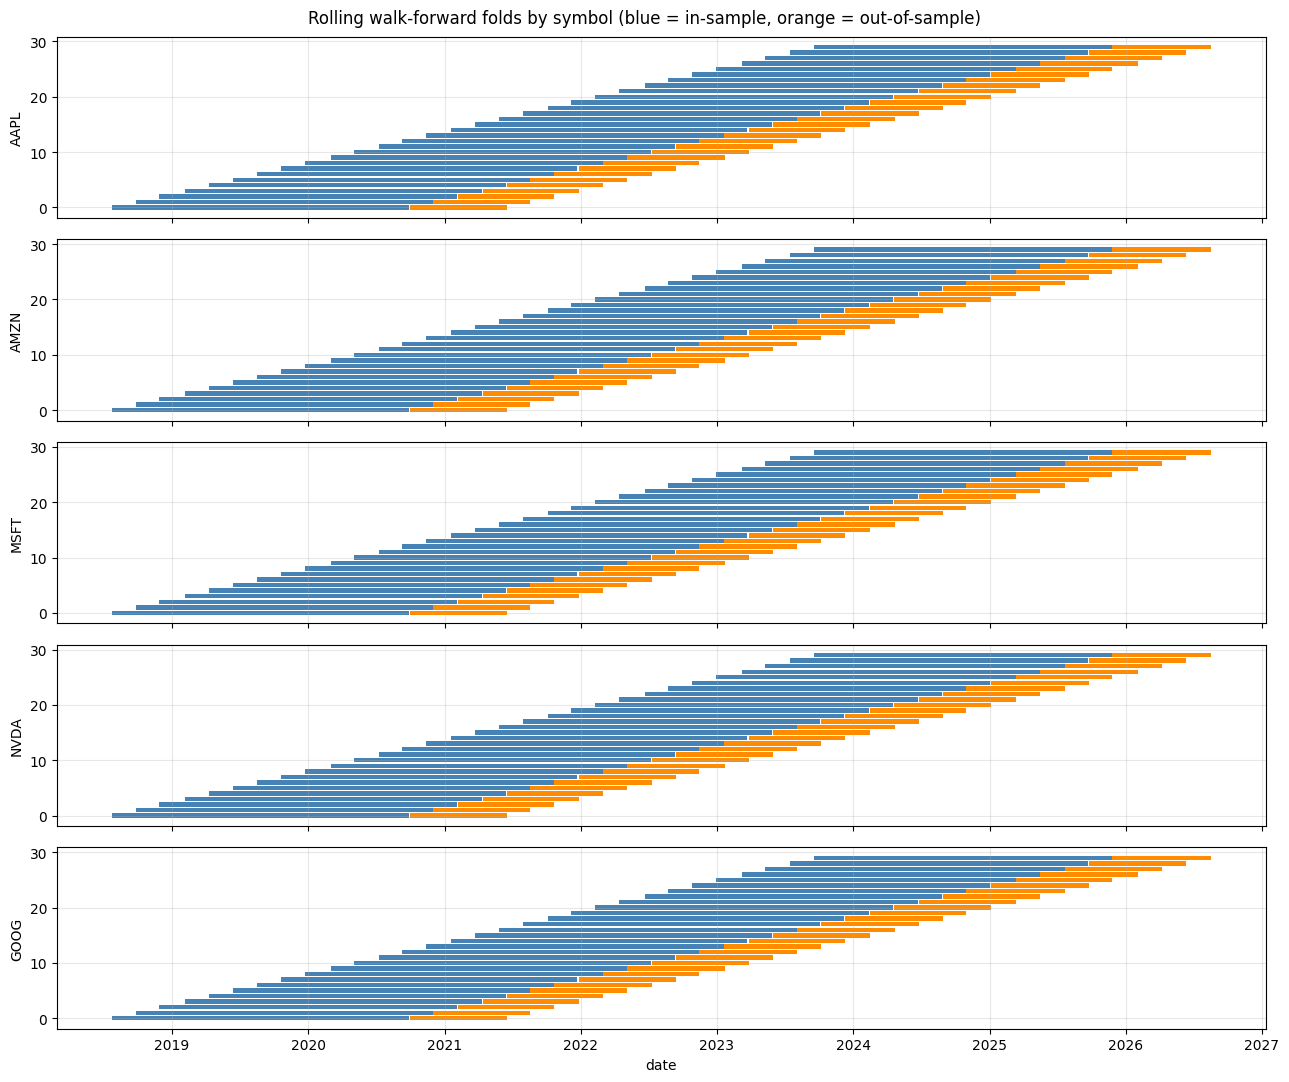

In [6]:
fig, axes = plt.subplots(len(splits), 1, figsize=(13, 2.2 * len(splits)), sharex=True)
axes = np.atleast_1d(axes)
for ax, (sym, s) in zip(axes, splits.items()):
    for split_idx in s["in_price"].columns:
        is_dates = s["in_indexes"][split_idx]
        oos_dates = s["out_indexes"][split_idx]
        ax.broken_barh([(is_dates.min(), is_dates.max() - is_dates.min())],
                        (split_idx - 0.4, 0.8), facecolors="steelblue")
        ax.broken_barh([(oos_dates.min(), oos_dates.max() - oos_dates.min())],
                        (split_idx - 0.4, 0.8), facecolors="darkorange")
    ax.set_ylabel(sym)
axes[-1].set_xlabel("date")
fig.suptitle("Rolling walk-forward folds by symbol (blue = in-sample, orange = out-of-sample)")
plt.tight_layout()
plt.show()

## 3. Core functions

`simulate_all_params` runs every `(fast, slow)` window COMBINATION
(`MA.run_combs` with `r=2`) across every split of a single symbol at once.
`get_best_index` / `get_best_params` pick the Sharpe-maximizing combo per
fold from the in-sample result. `simulate_best_params` then applies exactly
those winning, per-fold windows to the out-of-sample data (`per_column=True`
-- one scalar window per out-of-sample column, not another full grid).
These operate correctly on any single symbol's price Series, which is exactly
what the section 4 loop below feeds them.

In [ ]:
def simulate_all_params(price, windows, **kwargs):

    sharpe_results = []
    trade_results = []
    indexes = []

    for fast in windows:
        for slow in windows:
            if slow <= fast:
                continue

            fast_ma = vbt.MA.run(price, fast)
            slow_ma = vbt.MA.run(price, slow)

            entries = fast_ma.ma_crossed_above(slow_ma)
            exits = fast_ma.ma_crossed_below(slow_ma)

            pf = vbt.Portfolio.from_signals(price, entries, exits, **kwargs)
            sharpe = pf.sharpe_ratio()
            trades = pf.trades.count()

            sharpe = sharpe.iloc[0] if isinstance(sharpe, pd.Series) else sharpe
            trades = trades.iloc[0] if isinstance(trades, pd.Series) else trades
            
            if not np.isfinite(sharpe):
                sharpe = np.nan

            sharpe_results.append(sharpe)
            trade_results.append(trades)
            indexes.append((fast, slow))

    idx = pd.MultiIndex.from_tuples(indexes, names=["fast_window", "slow_window"])

    sharpe_series = pd.Series(sharpe_results, index=idx)
    trades_series = pd.Series(trade_results, index=idx)

    return sharpe_series, trades_series

def simulate_best_params(price, best_fast, best_slow, **kwargs):

    fast_ma = vbt.MA.run(price, best_fast)
    slow_ma = vbt.MA.run(price, best_slow)

    entries = fast_ma.ma_crossed_above(slow_ma)
    exits = fast_ma.ma_crossed_below(slow_ma)
        
    pf = vbt.Portfolio.from_signals(price, entries, exits, **kwargs)

    trades = pf.trades.count()
    exposure = pf.position_mask().mean()
    sharpe = pf.sharpe_ratio()

    trades = float(trades.iloc[0] if isinstance(trades, pd.Series) else trades)
    exposure = float(exposure.iloc[0] if isinstance(exposure, pd.Series) else exposure)
    sharpe = float(sharpe.iloc[0] if isinstance(sharpe, pd.Series) else sharpe)
        
    if trades < 3 or exposure == 0:
        return np.nan
        
    if not np.isfinite(sharpe):
        return np.nan
        
    return sharpe

## 4. Multi-asset walk-forward optimization

The main computation: for every symbol, grid the whole `(fast, slow)` window
space on each fold's in-sample segment, pick the Sharpe-maximizing combo per
fold, then apply that SAME fold's winning combo to its out-of-sample segment
-- the OOS data is never used for selection, only evaluation. Every later
section reads from this one `results` dict rather than recomputing anything,
so this cell is the only expensive one in the notebook
(`len(UNIVERSE) x N_SPLITS x C(len(WINDOWS), 2)` backtests in total --
reduce `WINDOWS`' range or `N_SPLITS` below for faster iteration).

In [8]:
WINDOWS = np.arange(10, 210, 10)

results = {}

print("Number of valid IS parameter combinations that passed the >=10 trades filter:")

for sym, s in splits.items():

    is_sharpe, trades_matrix = simulate_all_params(
        s["in_price"], 
        WINDOWS, 
        direction="both", 
        freq="1D"
    )

    is_sharpe = is_sharpe.replace([np.inf, -np.inf], np.nan)

    score = is_sharpe.copy()
    score[trades_matrix < 10] = np.nan

    valid_params = score.notna().sum()

    best_idx = score.idxmax()
    best_fast = best_idx[0]
    best_slow = best_idx[1]

    oos_sharpe = simulate_best_params(
        s["out_price"], 
        best_fast, 
        best_slow, 
        direction="both", 
        freq="1D"
    )

    if sym not in results:

        results[sym] = {
            "best_fast": best_fast,
            "best_slow": best_slow,
            "is_best": is_sharpe.loc[best_idx],
            "oos": oos_sharpe,
        }

    print(f"{sym}: {valid_params}")

Number of valid IS parameter combinations that passed the >=10 trades filter:
AAPL: 3
AMZN: 16
MSFT: 11
NVDA: 5
GOOG: 4


## 5. Combined fold-level results

Every symbol's per-fold winning windows and IS/OOS Sharpe, stacked into one
table -- the raw material every section below summarizes or visualizes.

In [9]:
fold_rows = []

for sym, r in results.items():

    fold_rows.append({
        "symbol": sym,
        "best_fast": r["best_fast"],
        "best_slow": r["best_slow"],
        "is_sharpe": round(r["is_best"], 4),
        "oos_sharpe": round(r["oos"], 4),
    })
    
fold_results = pd.DataFrame(fold_rows)
fold_results

,symbol,best_fast,best_slow,is_sharpe,oos_sharpe
0,AAPL,10,20,2.2921,-0.2945
1,AMZN,60,70,1.5458,-0.7698
2,MSFT,10,40,1.0262,-2.0332
3,NVDA,10,30,1.9267,-1.3674
4,GOOG,10,40,0.8721,0.2207


## 6. Statistical comparison (extended)

The test:

```python
t, p = stats.ttest_ind(a=out_sample_test, b=in_sample_best, alternative="greater")
```

testing whether OOS Sharpes are *significantly greater* than IS-best Sharpes.
Worth being direct about what that actually tells you: IS-best Sharpe is, by
construction, the maximum over a whole grid of candidates, so it's already
inflated by pure selection ("winner's curse"). OOS beating that inflated
number is a strong, somewhat surprising result if it happens -- it is NOT the
test most people reach for to check for overfitting.

The more standard overfitting check is the mirror image: is OOS
*significantly worse* than IS-best (`alternative="less"`)? That's the
direction that would actually indicate the window choice doesn't generalize.
Both are reported below, per symbol AND pooled across the whole universe, so
you can see the full picture rather than just a one-sided framing on a single name.

In [ ]:
WF_IS_DAYS = 252 * 2        # ~2 years in-sample
WF_OOS_DAYS = 63            # ~1 quarter out-of-sample
WF_STEP_DAYS = WF_OOS_DAYS  # move forward one OOS window

WINDOWS = np.arange(10, 210, 10)

def walk_forward_folds(index: pd.DatetimeIndex, is_days: int, oos_days: int, step_days: int):

    folds = []
    start = 0

    while start + is_days + oos_days <= len(index):

        is_start = start
        is_end = start + is_days

        oos_start = is_end
        oos_end = is_end + oos_days

        folds.append((is_start, is_end, oos_start, oos_end))

        start += step_days

    return folds

prices = all_prices

folds = walk_forward_folds(prices.index, WF_IS_DAYS, WF_OOS_DAYS, WF_STEP_DAYS)

print(
    f"{len(folds)} folds generated "
    f"(IS={WF_IS_DAYS}d, OOS={WF_OOS_DAYS}d, step={WF_STEP_DAYS}d)"
)

24 folds generated (IS=504d, OOS=63d, step=63d)


In [11]:
wf_splits = {}

for sym in prices.columns:
    wf_splits[sym] = []

    for fold_num, (is_start, is_end, oos_start, oos_end) in enumerate(folds):

        in_price = prices[sym].iloc[is_start:is_end]
        out_price = prices[sym].iloc[oos_start:oos_end]

        wf_splits[sym].append({
            "fold": fold_num,
            "in_price": in_price,
            "out_price": out_price,
            "in_start": in_price.index[0],
            "in_end": in_price.index[-1],
            "out_start": out_price.index[0],
            "out_end": out_price.index[-1],
        })

In [ ]:
def simulate_best_params(price, best_fast_windows, best_slow_windows, **kwargs):

    results = []

    for fast, slow in zip(best_fast_windows, best_slow_windows):

        fast_ma = vbt.MA.run(price, fast)
        slow_ma = vbt.MA.run(price, slow)

        entries = fast_ma.ma_crossed_above(slow_ma)
        exits = fast_ma.ma_crossed_below(slow_ma)

        pf = vbt.Portfolio.from_signals(price, entries, exits, **kwargs)

        sharpe = pf.sharpe_ratio()

        if isinstance(sharpe, pd.Series):
            sharpe = sharpe.iloc[0]

        if np.isfinite(sharpe):
            results.append(sharpe)
        else:
            results.append(np.nan)

    return pd.Series(results)

In [ ]:
wf_results = {}

print("Running 24-fold walk-forward optimization...\n")

for sym in prices.columns:

    wf_results[sym] = []

    for fold in wf_splits[sym]:

        fold_num = fold["fold"]
        in_price = fold["in_price"]
        out_price = fold["out_price"]

        is_sharpe, trades_matrix = simulate_all_params(
            in_price,
            WINDOWS,
            direction="both",
            freq="1D",
        )

        is_sharpe = is_sharpe.replace(
            [np.inf, -np.inf],
            np.nan,
        )

        score = is_sharpe.copy()
        score[trades_matrix < 10] = np.nan
        valid_params = score.notna().sum()


        if score.notna().sum() == 0:
            print(f"{sym} | fold {fold_num:2d} | NO VALID PARAMETERS")

            wf_results[sym].append({
                "fold": fold_num,
                "is_start": fold["in_start"],
                "is_end": fold["in_end"],
                "oos_start": fold["out_start"],
                "oos_end": fold["out_end"],
                "best_fast": np.nan,
                "best_slow": np.nan,
                "valid_params": 0,
                "is_sharpe": np.nan,
                "oos_sharpe": np.nan,
            })

            continue

        best_idx = score.idxmax()

        best_fast = best_idx[0]
        best_slow = best_idx[1]

        oos_sharpe = simulate_best_params(
            out_price,
            [best_fast],
            [best_slow],
            direction="both",
            freq="1D",
        )

        oos_value = oos_sharpe.iloc[0]
        
        if np.isnan(oos_value):
            oos_display = "NaN"
        else:
            oos_display = f"{oos_value:.2f}"

        wf_results[sym].append({
            "fold": fold_num,
            "is_start": fold["in_start"],
            "is_end": fold["in_end"],
            "oos_start": fold["out_start"],
            "oos_end": fold["out_end"],
            "best_fast": best_fast,
            "best_slow": best_slow,
            "valid_params": valid_params,
            "is_sharpe": is_sharpe.loc[best_idx],
            "oos_sharpe": oos_value,
        })

        print(
            f"{sym} | fold {fold_num:2d} | "
            f"best=({best_fast},{best_slow}) | "
            f"IS Sharpe={is_sharpe.loc[best_idx]:6.2f} | "
            f"OOS Sharpe={oos_display}"
        )

Running 24-fold walk-forward optimization...

AAPL | fold  0 | best=(10,20) | IS Sharpe=  2.18 | OOS Sharpe=0.02
AAPL | fold  1 | NO VALID PARAMETERS
AAPL | fold  2 | best=(20,40) | IS Sharpe=  1.81 | OOS Sharpe=-0.01
AAPL | fold  3 | best=(10,20) | IS Sharpe=  1.72 | OOS Sharpe=4.73
AAPL | fold  4 | best=(10,20) | IS Sharpe=  1.44 | OOS Sharpe=-1.50
AAPL | fold  5 | best=(10,20) | IS Sharpe=  1.22 | OOS Sharpe=4.23
AAPL | fold  6 | best=(10,20) | IS Sharpe=  1.54 | OOS Sharpe=-2.54
AAPL | fold  7 | best=(30,50) | IS Sharpe=  0.00 | OOS Sharpe=NaN
AAPL | fold  8 | best=(50,60) | IS Sharpe=  0.29 | OOS Sharpe=NaN
AAPL | fold  9 | best=(10,30) | IS Sharpe=  0.44 | OOS Sharpe=0.33
AAPL | fold 10 | best=(10,30) | IS Sharpe=  0.10 | OOS Sharpe=2.70
AAPL | fold 11 | best=(10,30) | IS Sharpe=  0.53 | OOS Sharpe=NaN
AAPL | fold 12 | best=(10,50) | IS Sharpe=  0.69 | OOS Sharpe=-3.78
AAPL | fold 13 | best=(30,40) | IS Sharpe=  0.45 | OOS Sharpe=-0.44
AAPL | fold 14 | best=(10,50) | IS Sharpe=  

In [ ]:
wf_stat_rows = {}

for sym, folds in wf_results.items():

    is_values = np.array([r["is_sharpe"] for r in folds if np.isfinite(r["is_sharpe"])])

    oos_values = np.array([
        r["oos_sharpe"]
        for r in folds
        if np.isfinite(r["oos_sharpe"])
    ])

    wf_stat_rows[sym] = {
        "n_is": len(is_values),
        "n_oos": len(oos_values),
        "mean_is_best": is_values.mean(),
        "mean_oos": oos_values.mean(),
    }

wf_stat_table = pd.DataFrame(wf_stat_rows).T

display(wf_stat_table)

,n_is,n_oos,mean_is_best,mean_oos
AAPL,23.0000,13.0000,0.9365,-0.0718
AMZN,24.0000,9.0000,1.1551,-0.8184
MSFT,24.0000,11.0000,0.7184,-0.7375
NVDA,24.0000,12.0000,1.3659,-0.4831
GOOG,24.0000,11.0000,1.0793,-1.2317


In [ ]:
ALPHA = 0.05

def run_walk_forward_tests(folds):

    is_values = np.array([r["is_sharpe"] for r in folds if np.isfinite(r["is_sharpe"]) and np.isfinite(r["oos_sharpe"])])
    oos_values = np.array([r["oos_sharpe"] for r in folds if np.isfinite(r["is_sharpe"]) and np.isfinite(r["oos_sharpe"])])

    decay = oos_values - is_values

    if len(decay) < 2:
        return {
            "n_folds": len(decay),
            "mean_is_best": np.nan,
            "mean_oos": np.nan,
            "mean_decay": np.nan,
            "t_stat": np.nan,
            "p_oos_less": np.nan,
            "p_two_sided": np.nan,
        }

    t_less, p_less = stats.ttest_1samp(decay, popmean=0, alternative="less")
    _, p_two = stats.ttest_1samp(decay, popmean=0, alternative="two-sided")

    return {
        "n_folds": len(decay),
        "mean_is_best": float(is_values.mean()),
        "mean_oos": float(oos_values.mean()),
        "mean_decay": float(decay.mean()),
        "t_stat": float(t_less),
        "p_oos_less": float(p_less),
        "p_two_sided": float(p_two),
    }


stat_rows = {sym: run_walk_forward_tests(folds) for sym, folds in wf_results.items()
}

stat_table = pd.DataFrame(stat_rows).T

stat_table["overfitting_signal"] = (stat_table["p_oos_less"] < ALPHA
)

display(stat_table)

,n_folds,mean_is_best,mean_oos,mean_decay,t_stat,p_oos_less,p_two_sided,overfitting_signal
AAPL,13.0000,1.1172,-0.0718,-1.1889,-1.6275,0.0648,0.1296,False
AMZN,9.0000,0.9797,-0.8184,-1.7981,-3.0305,0.0081,0.0163,True
MSFT,11.0000,0.6916,-0.7375,-1.4291,-1.9065,0.0428,0.0857,True
NVDA,12.0000,1.4429,-0.4831,-1.9260,-2.7774,0.0090,0.0180,True
GOOG,11.0000,1.1222,-1.2317,-2.3539,-3.8343,0.0016,0.0033,True


In [ ]:
def run_tests(is_values, oos_values):

    is_values = np.asarray(is_values, dtype=float)
    oos_values = np.asarray(oos_values, dtype=float)

    mask = (np.isfinite(is_values) & np.isfinite(oos_values))

    is_values = is_values[mask]
    oos_values = oos_values[mask]

    decay = oos_values - is_values

    if len(decay) < 2:
        return {
            "n_folds": len(decay),
            "mean_is_best": np.nan,
            "mean_oos": np.nan,
            "mean_decay": np.nan,
            "t_stat": np.nan,
            "p_oos_less": np.nan,
            "p_two_sided": np.nan,
        }

    t_less, p_less = stats.ttest_1samp(decay, popmean=0, alternative="less")
    _, p_two = stats.ttest_1samp(decay, popmean=0, alternative="two-sided")

    return {
        "n_folds": len(decay),
        "mean_is_best": float(is_values.mean()),
        "mean_oos": float(oos_values.mean()),
        "mean_decay": float(decay.mean()),
        "t_stat": float(t_less),
        "p_oos_less": float(p_less),
        "p_two_sided": float(p_two),
    }

In [ ]:
pooled_is = np.concatenate([np.array([fold["is_sharpe"] for fold in folds_sym]) for folds_sym in wf_results.values()])
pooled_oos = np.concatenate([
np.array([
        fold["oos_sharpe"]
        for fold in folds_sym])
    for folds_sym in wf_results.values()
])

pooled = run_tests(pooled_is, pooled_oos)

print(
    f"Pooled across {len(wf_results)} symbols, "
    f"{len(pooled_is)} paired fold observations:"
)
print(f"  Mean IS-best Sharpe:   {pooled['mean_is_best']:.3f}")
print(f"  Mean OOS Sharpe:      {pooled['mean_oos']:.3f}")
print(f"  OOS < IS-best:        {pooled['p_oos_less']:.4f}")
print(f"  Two-sided:          p={pooled['p_two_sided']:.4f}")
print(f"  Sharpe decay:         {pooled['mean_decay']:.3f}")

Pooled across 5 symbols, 120 paired fold observations:
  Mean IS-best Sharpe:   1.082
  Mean OOS Sharpe:      -0.639
  OOS < IS-best:        0.0000
  Two-sided:          p=0.0000
  Sharpe decay:         -1.721


**Caveats worth stating plainly, not burying:** The walk-forward results show substantial IS-to-OOS Sharpe deterioration, consistent with overfitting. However, the statistical p-values should be treated as a first-pass diagnostic rather than definitive hypothesis-test evidence. Walk-forward folds overlap in time, so observations across adjacent folds are not independent, and the stocks in the universe are also correlated. These dependencies reduce the effective sample size and can make conventional t-test p-values overly optimistic. Therefore, the magnitude and persistence of the IS-to-OOS decay are more informative at this stage than the exact p-value.

## 7. Parameter stability (per-symbol and cross-symbol)

A window choice that's wildly different from fold to fold -- or wildly
different from symbol to symbol -- is a sign the optimizer is fitting
fold/symbol-specific noise rather than a persistent pattern, worth knowing
regardless of what the Sharpe numbers say.

In [ ]:
stability_rows = {}

for sym, folds in wf_results.items():

    best_fast = np.array([fold["best_fast"] for fold in folds if np.isfinite(fold["best_fast"])])

    best_slow = np.array([
        fold["best_slow"]
        for fold in fold
        if np.isfinite(fold["best_slow"])
    ])


    if len(best_fast) == 0:
        stability_rows[sym] = {
            "modal_fast": np.nan,
            "fast_stability_pct": np.nan,
            "modal_slow": np.nan,
            "slow_stability_pct": np.nan,
            "fast_range": "N/A",
            "slow_range": "N/A",
        }
        continue

    fast_counts = pd.Series(best_fast).value_counts()
    slow_counts = pd.Series(best_slow).value_counts()

    stability_rows[sym] = {
        "modal_fast": fast_counts.idxmax(),
        "fast_stability_pct": (fast_counts.max() / fast_counts.sum() * 100),
        "modal_slow": slow_counts.idxmax(),
        "slow_stability_pct": (slow_counts.max() / slow_counts.sum() * 100),
        "fast_range": (f"[{best_fast.min()}, {best_fast.max()}]"),
        "slow_range": (f"[{best_slow.min()}, {best_slow.max()}]"),
    }

stability_table = pd.DataFrame(stability_rows).T
stability_table

,modal_fast,fast_stability_pct,modal_slow,slow_stability_pct,fast_range,slow_range
AAPL,10,52.1739,50,39.1304,"[10, 60]","[20, 70]"
AMZN,10,41.6667,30,33.3333,"[10, 110]","[20, 120]"
MSFT,50,37.5000,60,37.5000,"[10, 160]","[20, 170]"
NVDA,10,45.8333,40,29.1667,"[10, 60]","[20, 70]"
GOOG,10,33.3333,30,33.3333,"[10, 70]","[30, 80]"


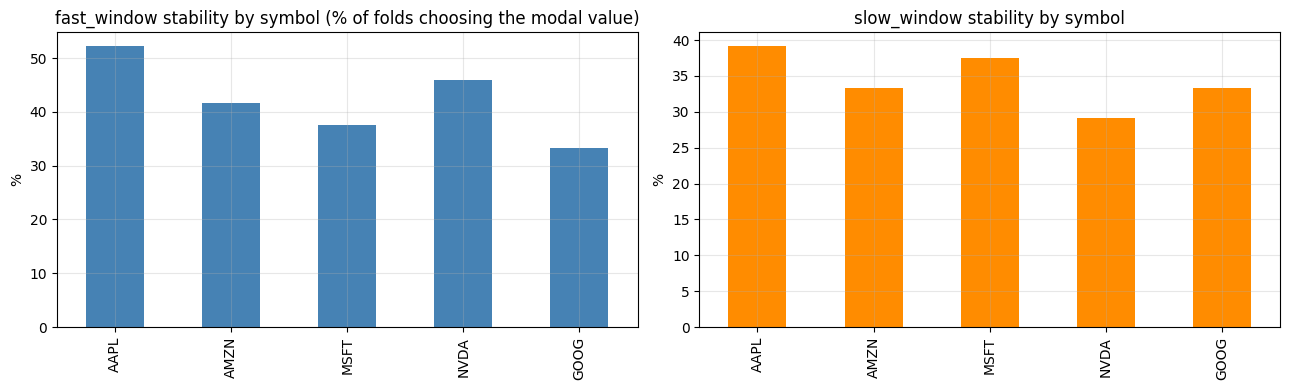

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
stability_table["fast_stability_pct"].astype(float).plot.bar(ax=axes[0], color="steelblue")
axes[0].set_title("fast_window stability by symbol (% of folds choosing the modal value)")
axes[0].set_ylabel("%")
stability_table["slow_stability_pct"].astype(float).plot.bar(ax=axes[1], color="darkorange")
axes[1].set_title("slow_window stability by symbol")
axes[1].set_ylabel("%")
plt.tight_layout()
plt.show()

## 8. Visualization

### 8a. Sharpe "surface" per symbol

The full `(fast, slow)` grid's Sharpe ratio for a representative fold, one
heatmap per symbol -- shows whether each name's optimum sits in a broad,
stable plateau (trustworthy) or a narrow, isolated spike (likely noise).

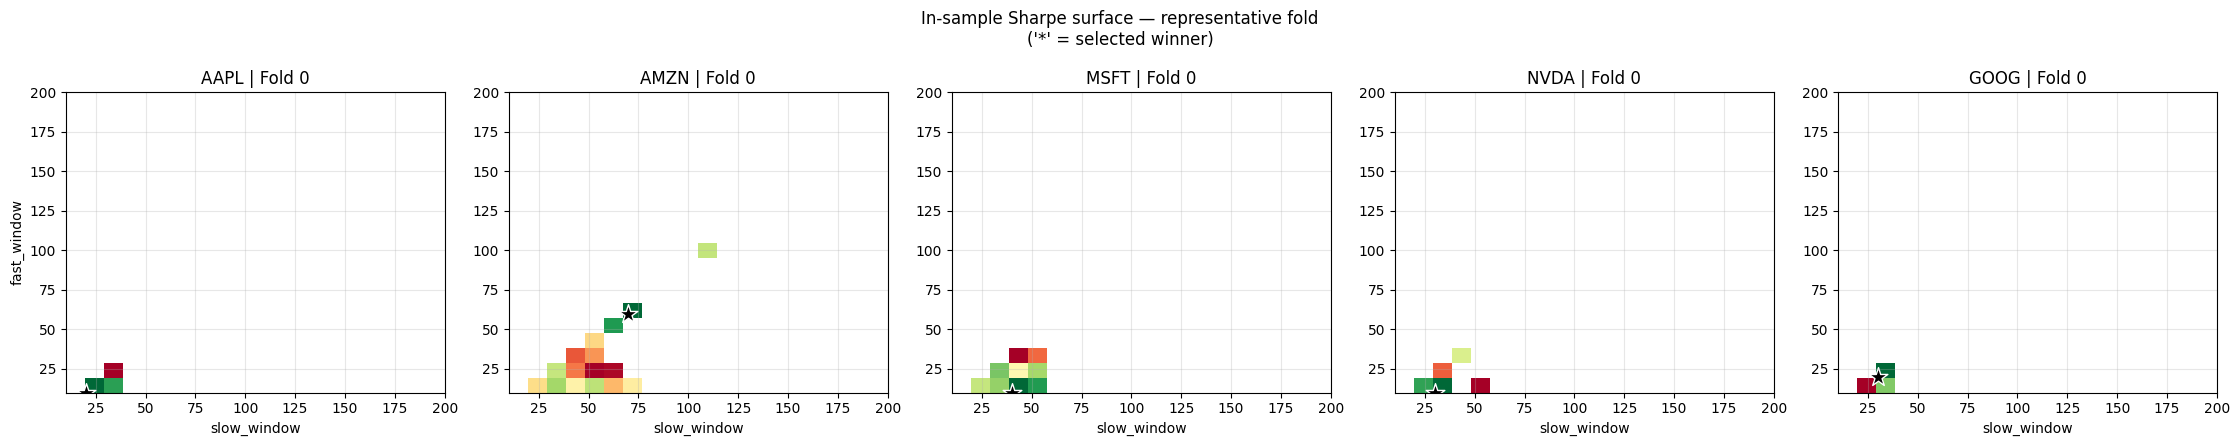

In [ ]:
REPRESENTATIVE_FOLD = 0

n_symbols = len(wf_results)

fig, axes = plt.subplots( 
    1,
    n_symbols,
    figsize=(4.5 * n_symbols, 4.5)
)

axes = np.atleast_1d(axes)

for ax, sym in zip(axes, wf_results.keys()):

    fold = wf_results[sym][REPRESENTATIVE_FOLD]

    in_price = None

    for f in wf_splits[sym]:
        if f["fold"] == REPRESENTATIVE_FOLD:
            in_price = f["in_price"]
            break

    is_sharpe, trades_matrix = simulate_all_params(
        in_price,
        WINDOWS,
        direction="both",
        freq="1D"
    )

    score = is_sharpe.replace([np.inf, -np.inf], np.nan)
    score[trades_matrix < 10] = np.nan

    sharpe_grid = (
        score
        .unstack("slow_window")
        .reindex(
            index=WINDOWS,
            columns=WINDOWS
        )
    )

    ax.imshow(sharpe_grid.values, cmap="RdYlGn", aspect="auto", origin="lower", extent=[WINDOWS.min(), WINDOWS.max(), WINDOWS.min(), WINDOWS.max()])

    ax.scatter(
        fold["best_slow"],
        fold["best_fast"],
        marker="*",
        s=200,
        color="black",
        edgecolor="white"
    )

    ax.set_title(f"{sym} | Fold {REPRESENTATIVE_FOLD}")
    ax.set_xlabel("slow_window")

axes[0].set_ylabel("fast_window")
plt.suptitle("In-sample Sharpe surface — representative fold ('*' = selected winner)")
plt.tight_layout()
plt.show()

### 8b. Parameter drift over time, overlaid across symbols

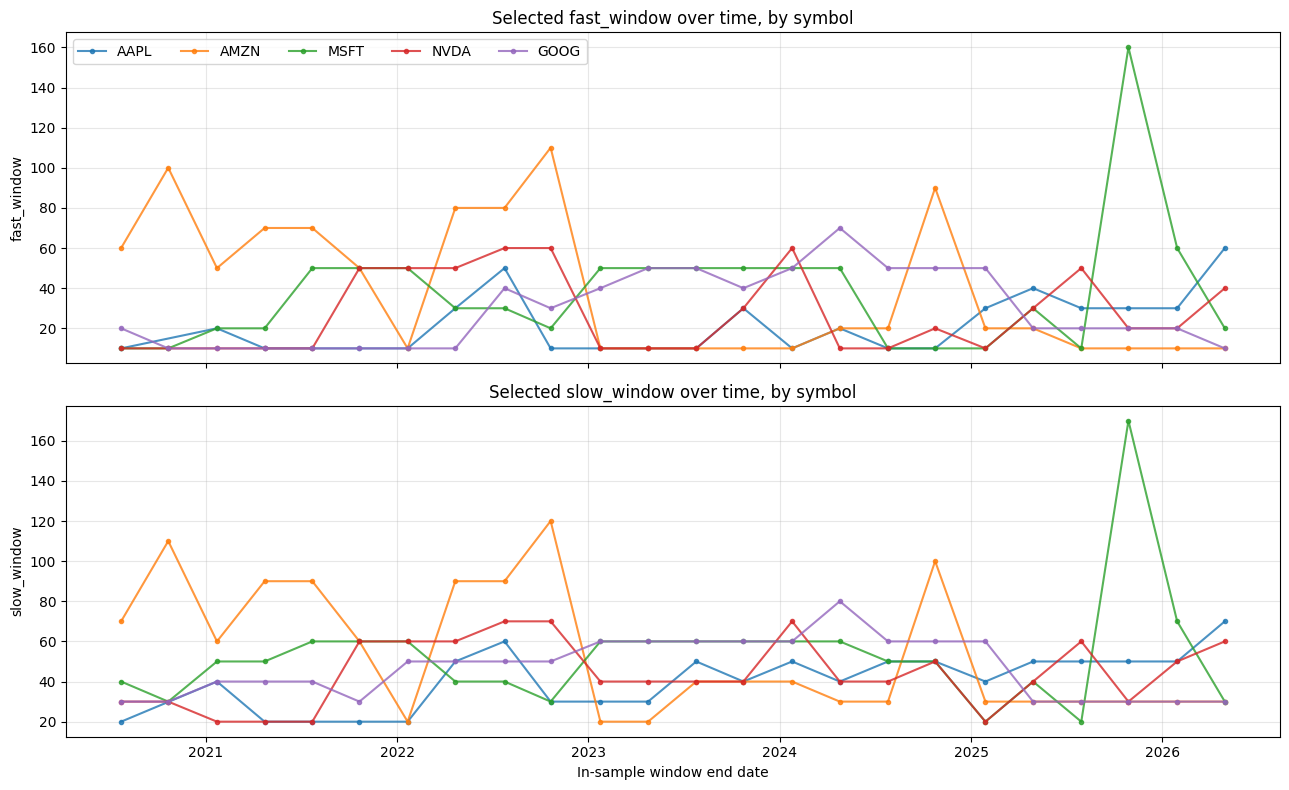

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

for sym, folds in wf_results.items():

    fold_dates = [fold["is_end"] for fold in folds if np.isfinite(fold["best_fast"])]

    fast_values = [fold["best_fast"] for fold in folds if np.isfinite(fold["best_fast"])]
    slow_values = [
        fold["best_slow"]
        for fold in folds
        if np.isfinite(fold["best_slow"])
    ]

    axes[0].plot(
        fold_dates,
        fast_values,
        marker=".",
        label=sym,
        alpha=0.8
    )

    axes[1].plot(
        fold_dates,
        slow_values,
        marker=".",
        label=sym,
        alpha=0.8
    )

axes[0].set_title("Selected fast_window over time, by symbol")
axes[1].set_title("Selected slow_window over time, by symbol")
axes[1].set_xlabel("In-sample window end date")
axes[0].set_ylabel("fast_window")
axes[1].set_ylabel("slow_window")

axes[0].legend(ncol=len(wf_results))

plt.tight_layout()
plt.show()

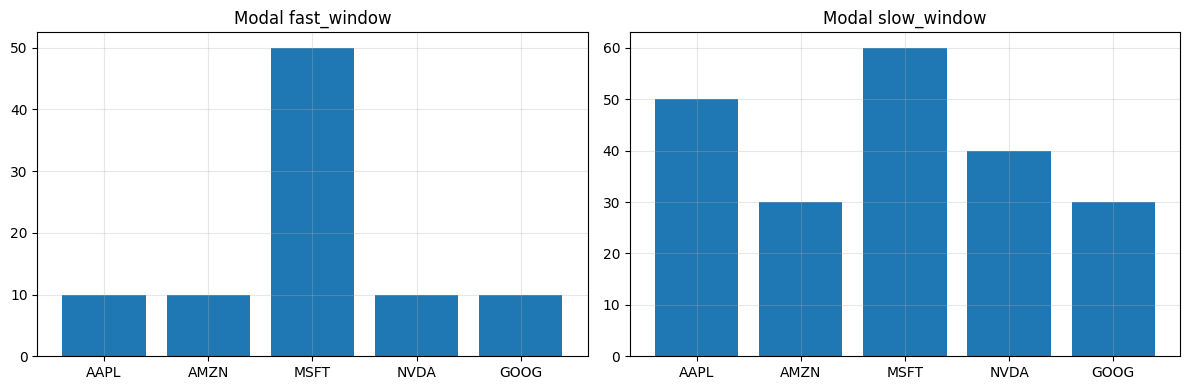

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
symbols = stability_table.index
fasts = stability_table["modal_fast"]
slows = stability_table["modal_slow"]
axes[0].bar(symbols, fasts)
axes[0].set_title("Modal fast_window")
axes[1].bar(symbols, slows)
axes[1].set_title("Modal slow_window")
plt.tight_layout()
plt.show()

### 8c. Modal window comparison across symbols

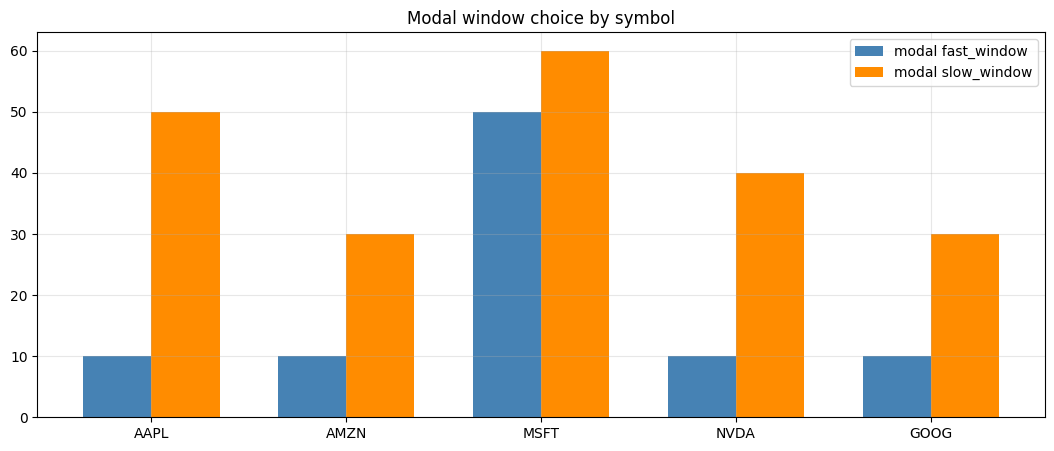

In [25]:
fig, ax = plt.subplots()
x = np.arange(len(stability_table))
width = 0.35
ax.bar(x - width/2, stability_table["modal_fast"].astype(float), width, label="modal fast_window", color="steelblue")
ax.bar(x + width/2, stability_table["modal_slow"].astype(float), width, label="modal slow_window", color="darkorange")
ax.set_xticks(x); ax.set_xticklabels(stability_table.index)
ax.set_title("Modal window choice by symbol")
ax.legend()
plt.show()

## 9. Cross-symbol scorecard

One row per symbol: is the window choice both statistically defensible
(section 6) and stable (section 7)? Ranked by OOS Sharpe, but the stability
and overfitting-signal columns matter as much as the raw number for deciding
whether to trust a given symbol's result.

In [ ]:
scorecard = pd.DataFrame({
    sym: {
        "mean_oos_sharpe": np.nanmean([fold["oos_sharpe"] for fold in folds if np.isfinite(fold["oos_sharpe"])]),
        "mean_is_best_sharpe": np.nanmean([fold["is_sharpe"] for fold in folds if np.isfinite(fold["is_sharpe"])]),
        "oos_minus_is": (np.nanmean([fold["oos_sharpe"] for fold in folds if np.isfinite(fold["oos_sharpe"])])
            - np.nanmean([fold["is_sharpe"] for fold in folds if np.isfinite(fold["is_sharpe"])
            ])
        ),
        "overfitting_signal": stat_table.loc[sym, "overfitting_signal"],
        "fast_stability_pct": stability_table.loc[sym, "fast_stability_pct"],
        "slow_stability_pct": stability_table.loc[sym, "slow_stability_pct"],
        "recommended_fast": stability_table.loc[sym, "modal_fast"],
        "recommended_slow": stability_table.loc[sym, "modal_slow"],
    }
    for sym, folds in wf_results.items()
}).T.sort_values("mean_oos_sharpe", ascending=False)
scorecard

,mean_oos_sharpe,mean_is_best_sharpe,oos_minus_is,overfitting_signal,fast_stability_pct,slow_stability_pct,recommended_fast,recommended_slow
AAPL,-0.0718,0.9365,-1.0083,False,52.1739,39.1304,10,50
NVDA,-0.4831,1.3659,-1.8490,True,45.8333,29.1667,10,40
MSFT,-0.7375,0.7184,-1.4559,True,37.5000,37.5000,50,60
AMZN,-0.8184,1.1551,-1.9734,True,41.6667,33.3333,10,30
GOOG,-1.2317,1.0793,-2.3110,True,33.3333,33.3333,10,30


## 10. Conclusions and how this feeds back

- **Window robustness (sections 4-8):** does the modal `(fast, slow)` pair
  hold across most folds for a given symbol (section 7), or does it swing
  every fold? Wide swings mean whatever number
  `config.StrategyConfig.fast_window`/`slow_window` currently holds should be
  treated as a rough starting point for that name, not a precise optimum.
- **Statistical significance (section 6):** did pooled OOS come out
  significantly worse than IS-best (the overfitting-check direction)? If so,
  this specific optimization procedure -- reselecting windows every fold --
  is not adding value over a fixed, sensible default, universe-wide.
- **Cross-symbol consistency (sections 7-9):** does one modal window pair
  work reasonably well across most of the universe, or does every symbol want
  something different? A single shared `config.StrategyConfig` default is
  only defensible if the answer looks like the former.
- **Feeding this back:** a stable, statistically-defensible window pair from
  here (see the scorecard) is a reasonable candidate for
  `config.StrategyConfig.fast_window`/`slow_window` -- either universe-wide if
  section 9 shows consistency, or per-symbol if it doesn't. Whatever comes
  out of this notebook still needs to go through `walk_forward.ipynb` for the
  full pipeline (position sizing, multi-asset allocation, execution) before
  it's anywhere near production -- this notebook only validates the
  indicator choice in isolation.